In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    #'text.usetex': True,
    'pgf.rcfonts': False,   # Fuente con serifa para coherencia con el texto
    "font.size": 11,          # Tamaño base
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 14,
    #"axes.titleweight": "bold",
    "grid.alpha": 0.1         # Rejilla más sutil
})

width = 5
height = width * 0.618

empresas_df = pd.read_parquet("../data/silver/iberinform_startups_certificadas.parquet", engine='pyarrow')
empresas_df['anno_constitucion'] = pd.to_datetime(
    empresas_df['fecha_constitucion'], errors='coerce').dt.year
empresas_df['comunidad_autonoma'] = empresas_df['comunidad_autonoma'].str.split(',').str[0].str.strip()
subset = empresas_df.copy()
poblacion_2024_df = pd.read_parquet("../data/silver/poblacion_2024.parquet", engine='pyarrow')
cpro_ccaa_dict = pd.read_csv("../data/silver/ine_ccaa_y_provincias.csv", sep=";", dtype=str).set_index('cpro')['codauto'].to_dict()
poblacion_2024_df['ccaa'] = poblacion_2024_df['cpro'].map(cpro_ccaa_dict)
poblacion_autonomica_2024_df = poblacion_2024_df.groupby('ccaa')['poblacion'].sum().reset_index()

# Distirbución de empresas según tramo de capital social

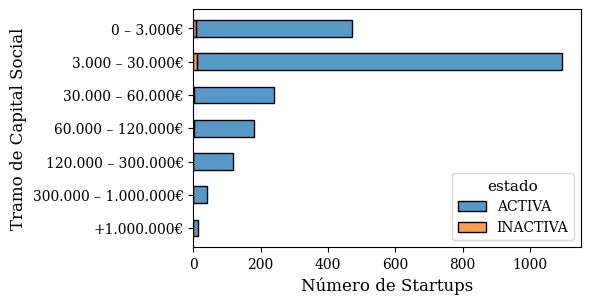

In [11]:
tramos_menores = ['0 – 3.000€', '3.000 – 30.000€', '30.000 – 60.000€']
tramos_mayores = ['60.000 – 120.000€', '120.000 – 300.000€',
                  '300.000 – 1.000.000€', '+1.000.000€']
orden_tramos = tramos_menores + tramos_mayores
subset = empresas_df[empresas_df['tramo_capital_social'].isin(orden_tramos)].copy()
subset['tramo_capital_social'] = pd.Categorical(
    subset['tramo_capital_social'], categories=orden_tramos, ordered=True)
plt.figure(figsize=(width, height))
#sns.set_theme(style="whitegrid")
ax = sns.histplot(data=subset, y='tramo_capital_social',
                  hue='estado', multiple="stack", shrink=0.5)

#plt.title(f'Distribución de Startups por Tramo de Capital Social ({subset["tramo_capital_social"].notnull().sum()} observaciones)')

plt.xlabel('Número de Startups')
plt.ylabel('Tramo de Capital Social')
#plt.savefig("../docs/manuscrito/recursos/figuras/distribucion_tramo_capital_social.pdf",
#            format='pdf',
#            bbox_inches='tight',
#            pad_inches=0.05)
plt.show()

# Medias y Varianzas de empresas creadas por años

In [12]:
cpros = pd.read_csv("../data/silver/ine_ccaa_y_provincias.csv", sep=";", dtype={'cpro': str})[['cpro']]
for anno in range(2016, 2027):
    tmp = empresas_df[empresas_df['anno_constitucion'] == anno].groupby('cpro').size().reset_index(name='count').copy()
    cpro = cpros.merge(tmp, on='cpro', how='left').fillna(0)
    print(f"media de startups creadas por provincia en {anno}: {cpro['count'].mean():.2f}")
    print(f"varianza de startups creadas por provincia en {anno}: {cpro['count'].var():.2f}")

cpro = cpros.merge(empresas_df.query("anno_constitucion>=2021 and anno_constitucion<=2024").groupby('cpro').size().reset_index(name='count').copy(), on='cpro', how='left').fillna(0)
print(f"media de startups accumuladas por provincia: {cpro['count'].mean():.2f}")
print(f"varianza de startups acumuladas por provincia: {cpro['count'].var():.2f}")

media de startups creadas por provincia en 2016: 0.02
varianza de startups creadas por provincia en 2016: 0.02
media de startups creadas por provincia en 2017: 0.54
varianza de startups creadas por provincia en 2017: 1.55
media de startups creadas por provincia en 2018: 1.13
varianza de startups creadas por provincia en 2018: 6.35
media de startups creadas por provincia en 2019: 2.96
varianza de startups creadas por provincia en 2019: 44.08
media de startups creadas por provincia en 2020: 5.98
varianza de startups creadas por provincia en 2020: 205.43
media de startups creadas por provincia en 2021: 7.19
varianza de startups creadas por provincia en 2021: 380.43
media de startups creadas por provincia en 2022: 6.48
varianza de startups creadas por provincia en 2022: 259.74
media de startups creadas por provincia en 2023: 7.71
varianza de startups creadas por provincia en 2023: 357.42
media de startups creadas por provincia en 2024: 5.52
varianza de startups creadas por provincia en 202

# Distribución de empresas por comunidad autónoma

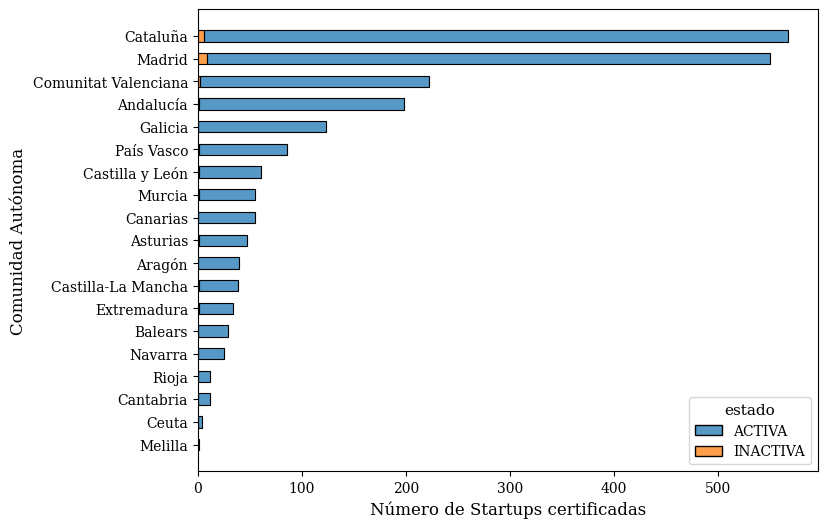

In [13]:
plt.figure(figsize=(8, 6))

empresas_df['categoria_ubicacion'] = pd.Categorical(
    empresas_df['comunidad_autonoma'], categories=empresas_df['comunidad_autonoma'].value_counts().index.tolist(), ordered=True)

ax = sns.histplot(data=empresas_df, y='categoria_ubicacion',
                  hue='estado', multiple="stack", shrink=0.5)

plt.xlabel('Número de Startups certificadas')
plt.ylabel('Comunidad Autónoma')

#plt.savefig("../docs/manuscrito/recursos/figuras/distribucion-startups-ccaa.pdf",
#            format='pdf',
#            bbox_inches='tight',
#            pad_inches=0.05)
plt.show()

# Distribución en términos absolutos contra normalizada por población

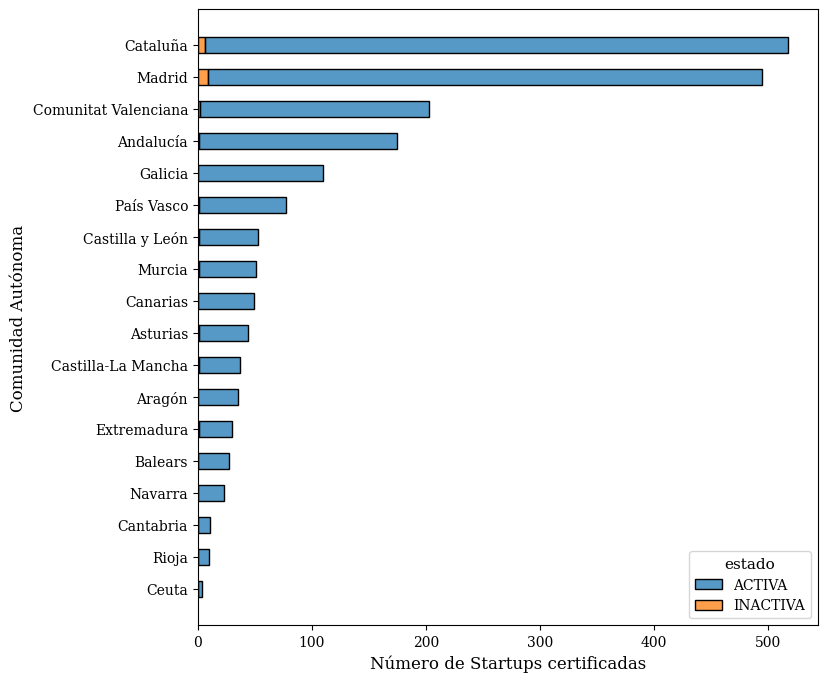

In [14]:
plt.figure(figsize=(8, 8))


subset = empresas_df.query("anno_constitucion <= 2024").copy().reset_index(drop=True)
subset['comunidad_autonoma'] = subset['comunidad_autonoma'].str.split(',').str[0].str.strip()
subset['categoria_ubicacion'] = pd.Categorical(
    subset['comunidad_autonoma'], categories=subset['comunidad_autonoma'].value_counts().index.tolist(), ordered=True)
subset = subset.merge(poblacion_autonomica_2024_df, on='ccaa', how='left')
ax = sns.histplot(data=subset, y='categoria_ubicacion',
                  hue='estado', multiple="stack", shrink=0.5)


plt.xlabel('Número de Startups certificadas')
plt.ylabel('Comunidad Autónoma')

#plt.savefig("../docs/manuscrito/recursos/figuras/distribucion-startups-ccaa-2024.pdf",
#            format='pdf',
#            bbox_inches='tight',
#            pad_inches=0.05)
plt.show()

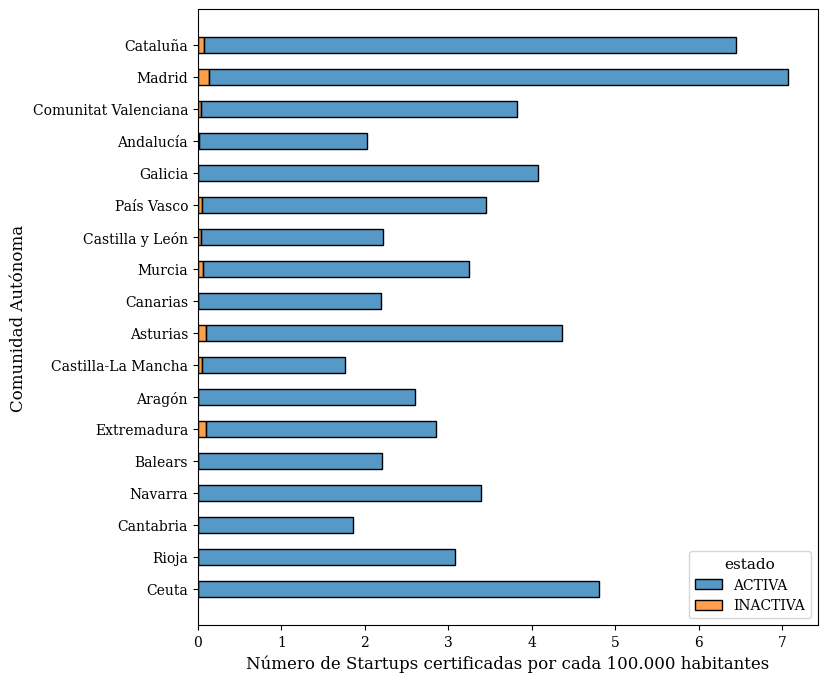

In [15]:
plt.figure(figsize=(8, 8))


subset = empresas_df.query("anno_constitucion <= 2024").copy().reset_index(drop=True)
subset['comunidad_autonoma'] = subset['comunidad_autonoma'].str.split(',').str[0].str.strip()
subset['categoria_ubicacion'] = pd.Categorical(
    subset['comunidad_autonoma'], categories=subset['comunidad_autonoma'].value_counts().index.tolist(), ordered=True)
subset = subset.merge(poblacion_autonomica_2024_df, on='ccaa', how='left')
subset['peso_100k'] = 100000 / subset['poblacion']
ax = sns.histplot(data=subset, y='categoria_ubicacion',
                  hue='estado', multiple="stack", shrink=0.5, weights='peso_100k')


plt.xlabel('Número de Startups certificadas por cada 100.000 habitantes')
plt.ylabel('Comunidad Autónoma')

#plt.savefig("../docs/manuscrito/recursos/figuras/distribucion-startups-ccaa-100k-2024.pdf",
#            format='pdf',
#            bbox_inches='tight',
#            pad_inches=0.05)
plt.show()

# Mapa de distribución por provincias

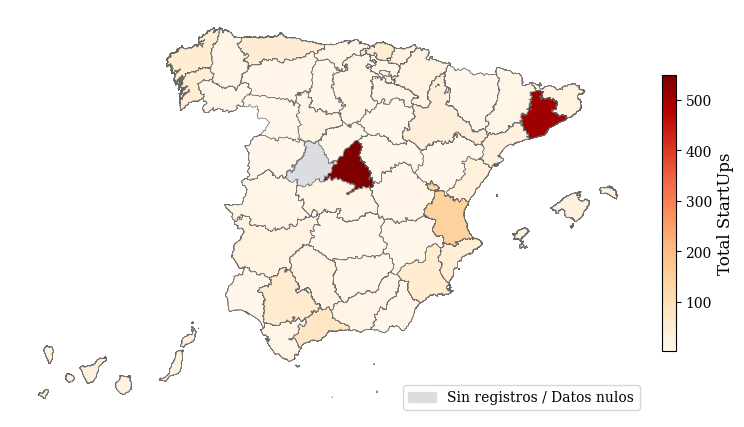

In [16]:
import geopandas as gpd
from src.analysis.visuals import generar_mapa
url_geojson_provinces = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/spain-provinces.geojson"
gdf_provinces = gpd.read_file(url_geojson_provinces)
subset = empresas_df.copy()
subset['Total StartUps'] = subset.groupby('cpro')['cpro'].transform('count')

generar_mapa(gdf_provinces, subset, 'cpro', 'Total StartUps', col_valor_label='Número de Startups', width=8)

# Mapa de calor, distribución de capital social por CCAA

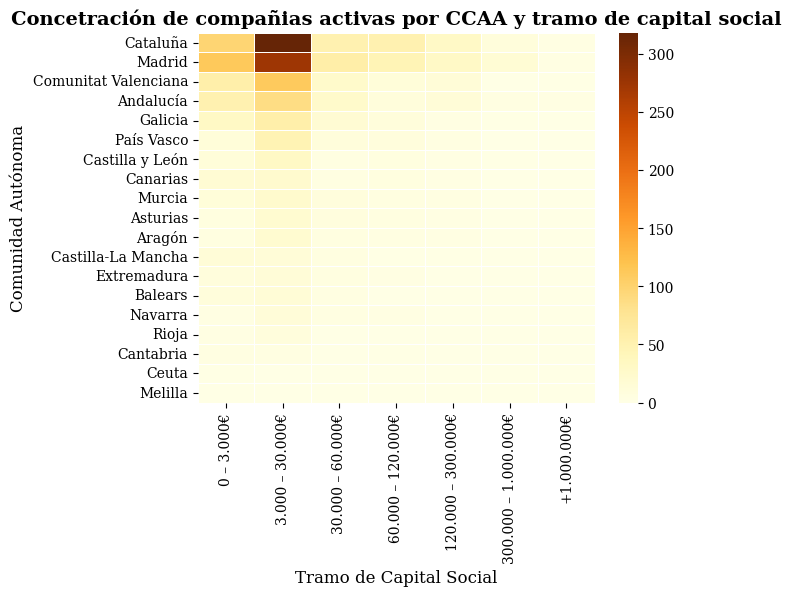

In [17]:
activos_df = empresas_df[empresas_df['estado'] == 'ACTIVA'].copy().reset_index(drop=True)
activos_df['comunidad_autonoma'] = activos_df['comunidad_autonoma'].str.split(',').str[0].str.strip()
active_heatmap_data = pd.crosstab(
    activos_df['comunidad_autonoma'],activos_df['tramo_capital_social'])
orden_comunidades = activos_df['comunidad_autonoma'].value_counts().index.tolist()
active_heatmap_data = active_heatmap_data.reindex(orden_comunidades)
tramos_menores = ['0 – 3.000€', '3.000 – 30.000€', '30.000 – 60.000€']
tramos_mayores = ['60.000 – 120.000€', '120.000 – 300.000€',
                  '300.000 – 1.000.000€', '+1.000.000€']
orden_tramos = tramos_menores + tramos_mayores

active_heatmap_data = active_heatmap_data.reindex(columns=orden_tramos)
# Create the heatmap
sns.heatmap(
    active_heatmap_data,
    annot=False,       # Shows the actual numbers inside the squares
    #fmt="d",          # Formats annotations as integers
    cmap="YlOrBr",    # Yellow-Orange-Brown color palette
    linewidths=.5     # Adds gridlines between cells
)

plt.title('Concetración de compañias activas por CCAA y tramo de capital social')
plt.xlabel('Tramo de Capital Social')
plt.ylabel('Comunidad Autónoma')
plt.show()


# Distribución temporal de creación de empresas según capital social

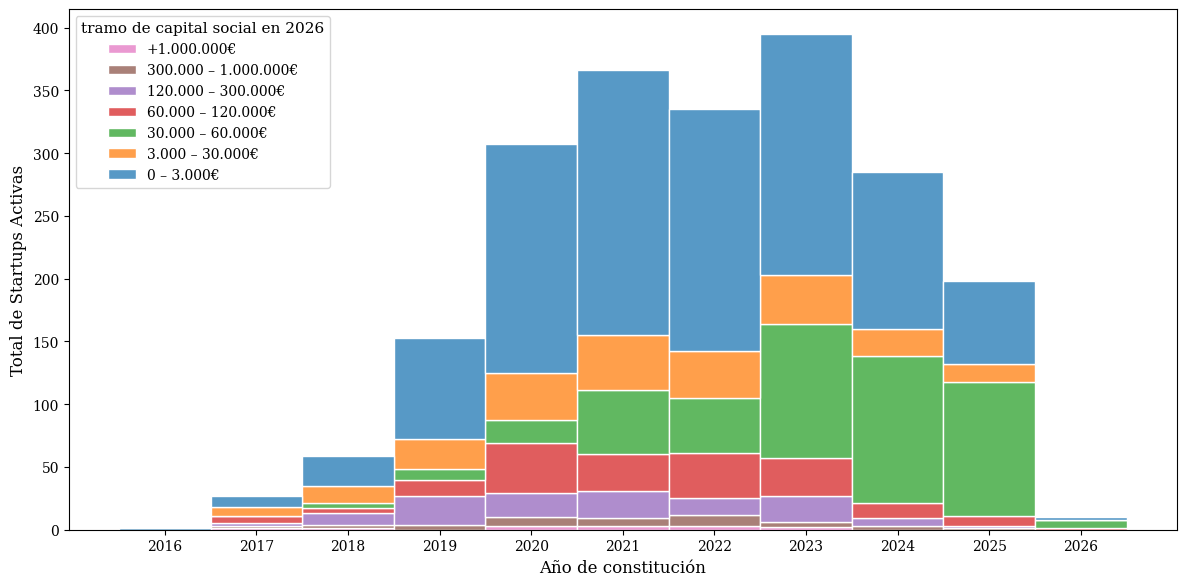

In [18]:
plt.figure(figsize=(12, 6))
subset = empresas_df.query("estado == 'ACTIVA' and anno_constitucion.notnull()").copy()
# Create the stacked bar chart
sns.histplot(
    data=subset,
    x='anno_constitucion',
    hue='tramo_capital_social',
    multiple='stack',
    discrete=True,       # Ensures bars align perfectly with integer years
    palette='tab10',   # A colorblind-friendly palette
    edgecolor='white'
)

#plt.title('Company Creation over Time, Stacked by Capital Bracket')
plt.xticks(range(subset['anno_constitucion'].astype(int).min(),
             subset['anno_constitucion'].astype(int).max()+1))  # Set x-ticks every 5 years
plt.xlabel('Año de constitución')
plt.ylabel('Total de Startups Activas')

# Move legend outside the plot
plt.legend(title='tramo de capital social en 2026',
           labels=orden_tramos[::-1])
plt.tight_layout()
#plt.savefig("../docs/manuscrito/recursos/figuras/anno-constitucion-tramo-capital.pdf",
#            format='pdf',
#            bbox_inches='tight',
#            pad_inches=0.05)
plt.show()

In [19]:
subset.query("tramo_capital_social == '+1.000.000€'")[['denominacion','municipio','provincia','fecha_constitucion', 'grupo_cnae','descripcion_grupo_cnae','objeto_social']]
subset.query("tramo_capital_social == '+1.000.000€'")['objeto_social'].to_list()

['La Creacion, Mantenimiento, Y Gestion De Paginas Y Portales Web Y App, Asi Como El Manejo, Elaboracion E Instalacion De Cualquier Tipo De Software O Programa Informatico. La Realizacion De Actividades Relativas A La Transmision Y Tratamiento De Datos, Hosting, Accesos Y Servicios Para Internet.....',
 'Construccion De Redes Electricas Y De Telecomunicaciones.',
 'La Planificacion, Desarrollo Y Comercializacion De Una Aplicacion Movil Y Una Pagina Web Dedicadas A Las Siguientes Actividades: La Comercializacion De Productos Financieros Para Particulares Y Empresas, La Intermediacion En La Contratacion De Los Mencionados Productos Y La Prestacion De Servicios.. La Realizacion De La Actividad De Intermediacion En La Venta Y Distribucion De Seguros Como Agencia De Seguros Exclusiva Con Expreso Sometimiento A La Legislacion Especifica De Distribucion De Seguros Privados Vigente En Cada Momento. La Realizacion De Todas Las Actividades Relacionadas Con ...',
 'Fabricacion, Compra, Venta, Mod

# Estructura de capital social por comunidad autónoma

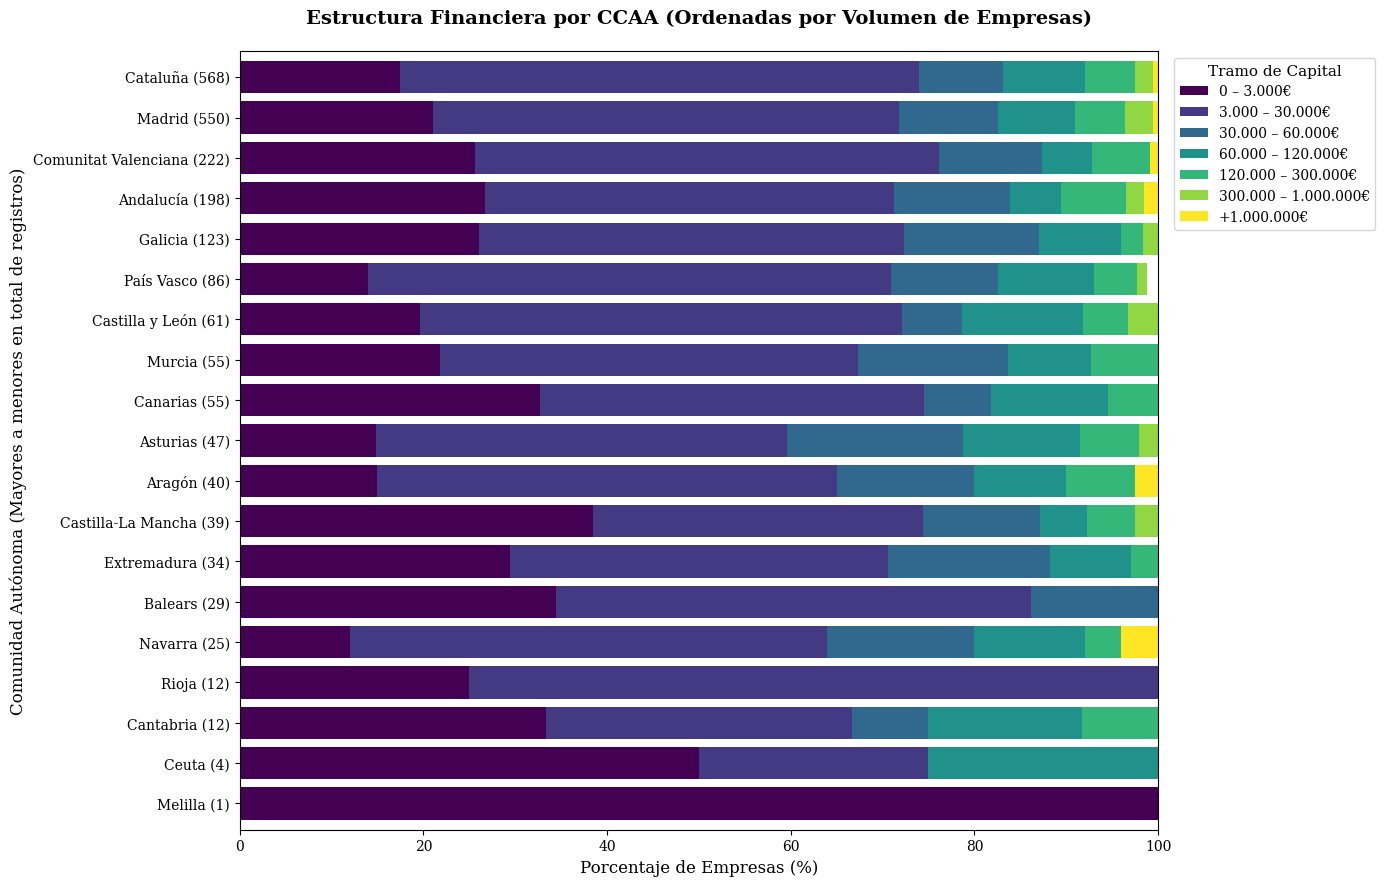

In [20]:
import pandas as pd
import seaborn as sns

tramos_menores = ['0 – 3.000€', '3.000 – 30.000€', '30.000 – 60.000€']
tramos_mayores = ['60.000 – 120.000€', '120.000 – 300.000€',
                  '300.000 – 1.000.000€', '+1.000.000€']
orden_tramos = tramos_menores + tramos_mayores
# 1. Calculamos el orden basado en el total de empresas
# Usamos .index para obtener los nombres de las CCAA de mayor a menor volumen
orden_volumen = empresas_df['comunidad_autonoma'].value_counts().index[::-1]

# 2. Creamos la tabla cruzada normalizada
ct = pd.crosstab(empresas_df['comunidad_autonoma'],
                 empresas_df['tramo_capital_social'],
                 normalize='index') * 100

# 3. REORDENAMOS la tabla según el volumen calculado en el paso 1
ct_ordenada = ct.reindex(orden_volumen,columns=orden_tramos)

# 4. Graficamos (usamos invert_yaxis si queremos que la más grande esté arriba)
ax = ct_ordenada.plot(kind='barh', 
                      stacked=True, 
                      figsize=(14, 9), 
                      colormap='viridis', 
                      width=0.8,
                      edgecolor='none',
                      linewidth=0)

plt.title('Estructura Financiera por CCAA (Ordenadas por Volumen de Empresas)',
          fontsize=14, pad=20)
plt.xlabel('Porcentaje de Empresas (%)', fontsize=12)
plt.ylabel(
    'Comunidad Autónoma (Mayores a menores en total de registros)', fontsize=12)
plt.legend(title='Tramo de Capital',
           bbox_to_anchor=(1.01, 1), loc='upper left')

# Añadir el total de N al lado de cada barra para mayor claridad
ns = {}
for i, (nombre, fila) in enumerate(ct_ordenada.iterrows()):
    ns[nombre] = empresas_df[empresas_df['comunidad_autonoma'] == nombre].shape[0]
nuevas_etiquetas = [f"{ccaa} ({ns.get(ccaa)})" for ccaa in ct_ordenada.index]
plt.yticks(range(len(nuevas_etiquetas)), nuevas_etiquetas)
plt.grid(False)
plt.tight_layout()
plt.show()

# composición de actividad por comunidad autónoma

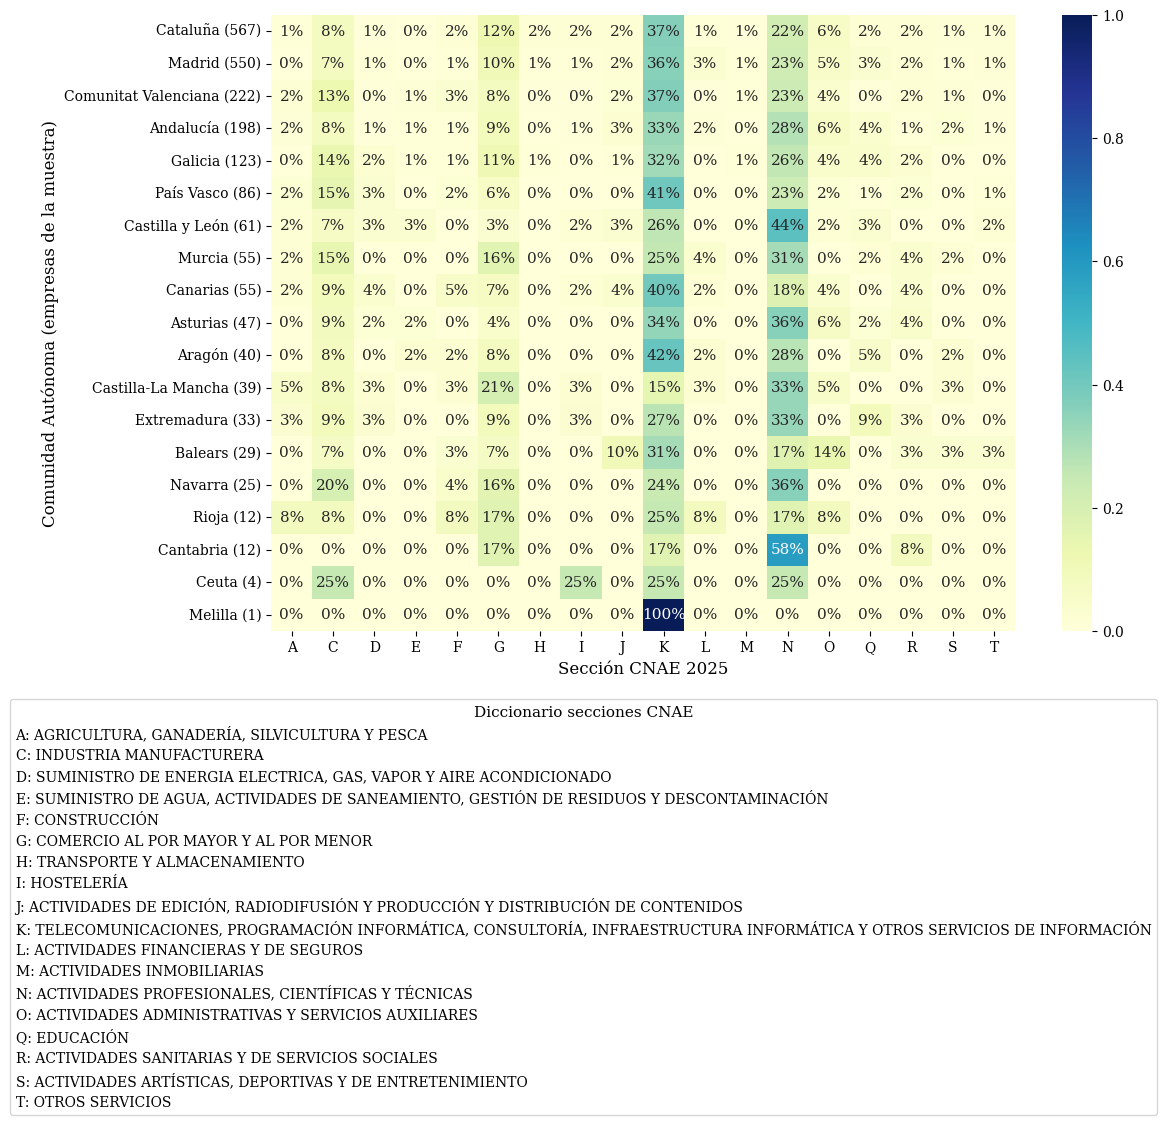

In [21]:
import matplotlib.patches as mpatches

label_dict = empresas_df[['seccion_cnae', 'descripcion_seccion_cnae']].drop_duplicates(
).set_index('seccion_cnae')['descripcion_seccion_cnae'].to_dict()
empresas_df['comunidad_autonoma'] = empresas_df['comunidad_autonoma'].str.split(
    ',').str[0].str.strip()
orden_volumen = empresas_df['comunidad_autonoma'].value_counts().index
plt.figure(figsize=(12, 8))
tabla_pct = pd.crosstab(
    empresas_df['comunidad_autonoma'], empresas_df['seccion_cnae'], normalize='index')
tabla_pct = tabla_pct.reindex(orden_volumen)
totales_por_ccaa = pd.crosstab(
    empresas_df['comunidad_autonoma'], empresas_df['seccion_cnae'], margins=True, margins_name="total")['total'].to_dict()
tabla_pct.index = [
    f"{ccaa} ({totales_por_ccaa[ccaa]})" for ccaa in tabla_pct.index]
ax = sns.heatmap(tabla_pct,
                 annot=True,    # Muestra los números
                 fmt='.0%',     # Formato porcentaje sin decimales (ej. 25%)
                 cmap='YlGnBu')  # Paleta de colores
plt.xlabel("Sección CNAE 2025")
plt.ylabel("Comunidad Autónoma (empresas de la muestra)")

#plt.title("Distribución Porcentual de la actividad de las empresas emergentes según CCAA")

visible_ticks = [t.get_text() for t in ax.get_xticklabels()]

# Create handles ONLY for the keys found on the axis
legend_handles = []
for key in visible_ticks:
    if key in label_dict:
        # Create the text-only entry
        label_text = f"{key}: {label_dict[key]}"
        handle = mpatches.Patch(color='none', label=label_text)
        legend_handles.append(handle)

plt.legend(
    handles=legend_handles,
    bbox_to_anchor=(0.42, -0.1),   # Move legend outside to the right
    loc='upper center',          # Anchor point
    title="Diccionario secciones CNAE",       # Title for the legend
    handlelength=0,
    handletextpad=0,
    frameon=True                # Add a box around the legend
)
#plt.savefig("../docs/manuscrito/recursos/figuras/matriz-actividad-ccaa.pdf",
#            format='pdf',
#            bbox_inches='tight',
#            pad_inches=0.05)
plt.show()

# Detalle K y N

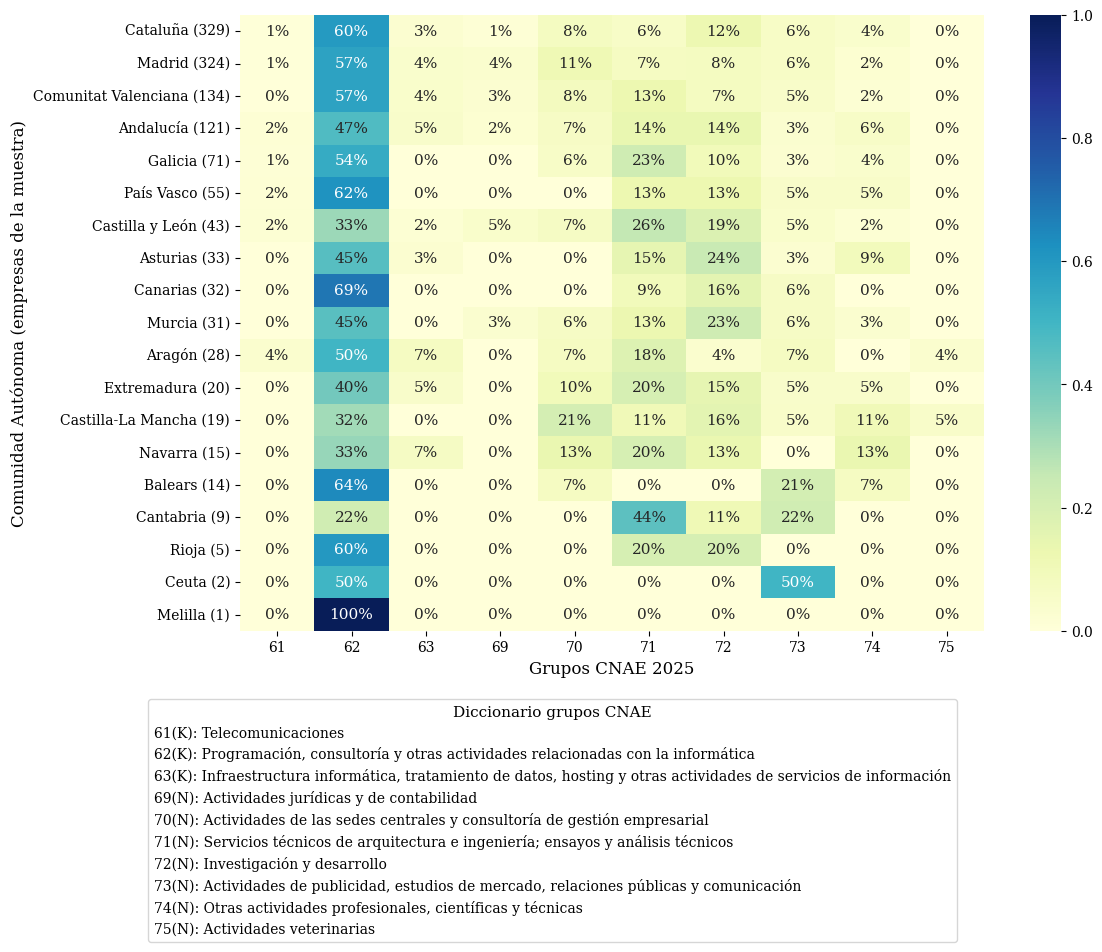

In [22]:
subset_k_n = empresas_df.query("seccion_cnae.isin(['K','N'])").copy()
label_dict = subset_k_n[['grupo_cnae', 'descripcion_grupo_cnae']].drop_duplicates(
).set_index('grupo_cnae')['descripcion_grupo_cnae'].to_dict()
subset_k_n['comunidad_autonoma'] = subset_k_n['comunidad_autonoma'].str.split(
    ',').str[0].str.strip()
orden_volumen = subset_k_n['comunidad_autonoma'].value_counts().index
plt.figure(figsize=(12, 8))
tabla_pct = pd.crosstab(
    subset_k_n['comunidad_autonoma'], subset_k_n['grupo_cnae'], normalize='index')
tabla_pct = tabla_pct.reindex(orden_volumen)
totales_por_ccaa = pd.crosstab(
    subset_k_n['comunidad_autonoma'], subset_k_n['grupo_cnae'], margins=True, margins_name="total")['total'].to_dict()
tabla_pct.index = [
    f"{ccaa} ({totales_por_ccaa[ccaa]})" for ccaa in tabla_pct.index]
ax = sns.heatmap(tabla_pct,
                 annot=True,    # Muestra los números
                 fmt='.0%',     # Formato porcentaje sin decimales (ej. 25%)
                 cmap='YlGnBu')  # Paleta de colores
plt.xlabel("Grupos CNAE 2025")
plt.ylabel("Comunidad Autónoma (empresas de la muestra)")

#plt.title("Distribución Porcentual de la actividad de las empresas emergentes según CCAA")

visible_ticks = [t.get_text() for t in ax.get_xticklabels()]

# Create handles ONLY for the keys found on the axis
cnae_2025_df = pd.read_csv(
    "../data/silver/cnae_2025.csv", sep=";", dtype=str)
grupo_seccion_dict = cnae_2025_df.set_index('grupo')['seccion'].to_dict()
legend_handles = []
for key in visible_ticks:
    if key in label_dict:
        # Create the text-only entry
        label_text = f"{key}({grupo_seccion_dict.get(key, 'N/A')}): {label_dict[key]}"
        handle = mpatches.Patch(color='none', label=label_text)
        legend_handles.append(handle)

plt.legend(
    handles=legend_handles,
    bbox_to_anchor=(0.42, -0.1),   # Move legend outside to the right
    loc='upper center',          # Anchor point
    title="Diccionario grupos CNAE",       # Title for the legend
    handlelength=0,
    handletextpad=0,
    frameon=True                # Add a box around the legend
)
#plt.savefig("../docs/manuscrito/recursos/figuras/matriz-actividad-ccaa-k-n.pdf",
#            format='pdf',
#            bbox_inches='tight',
#            pad_inches=0.05)
plt.show()

# Detalles C y G

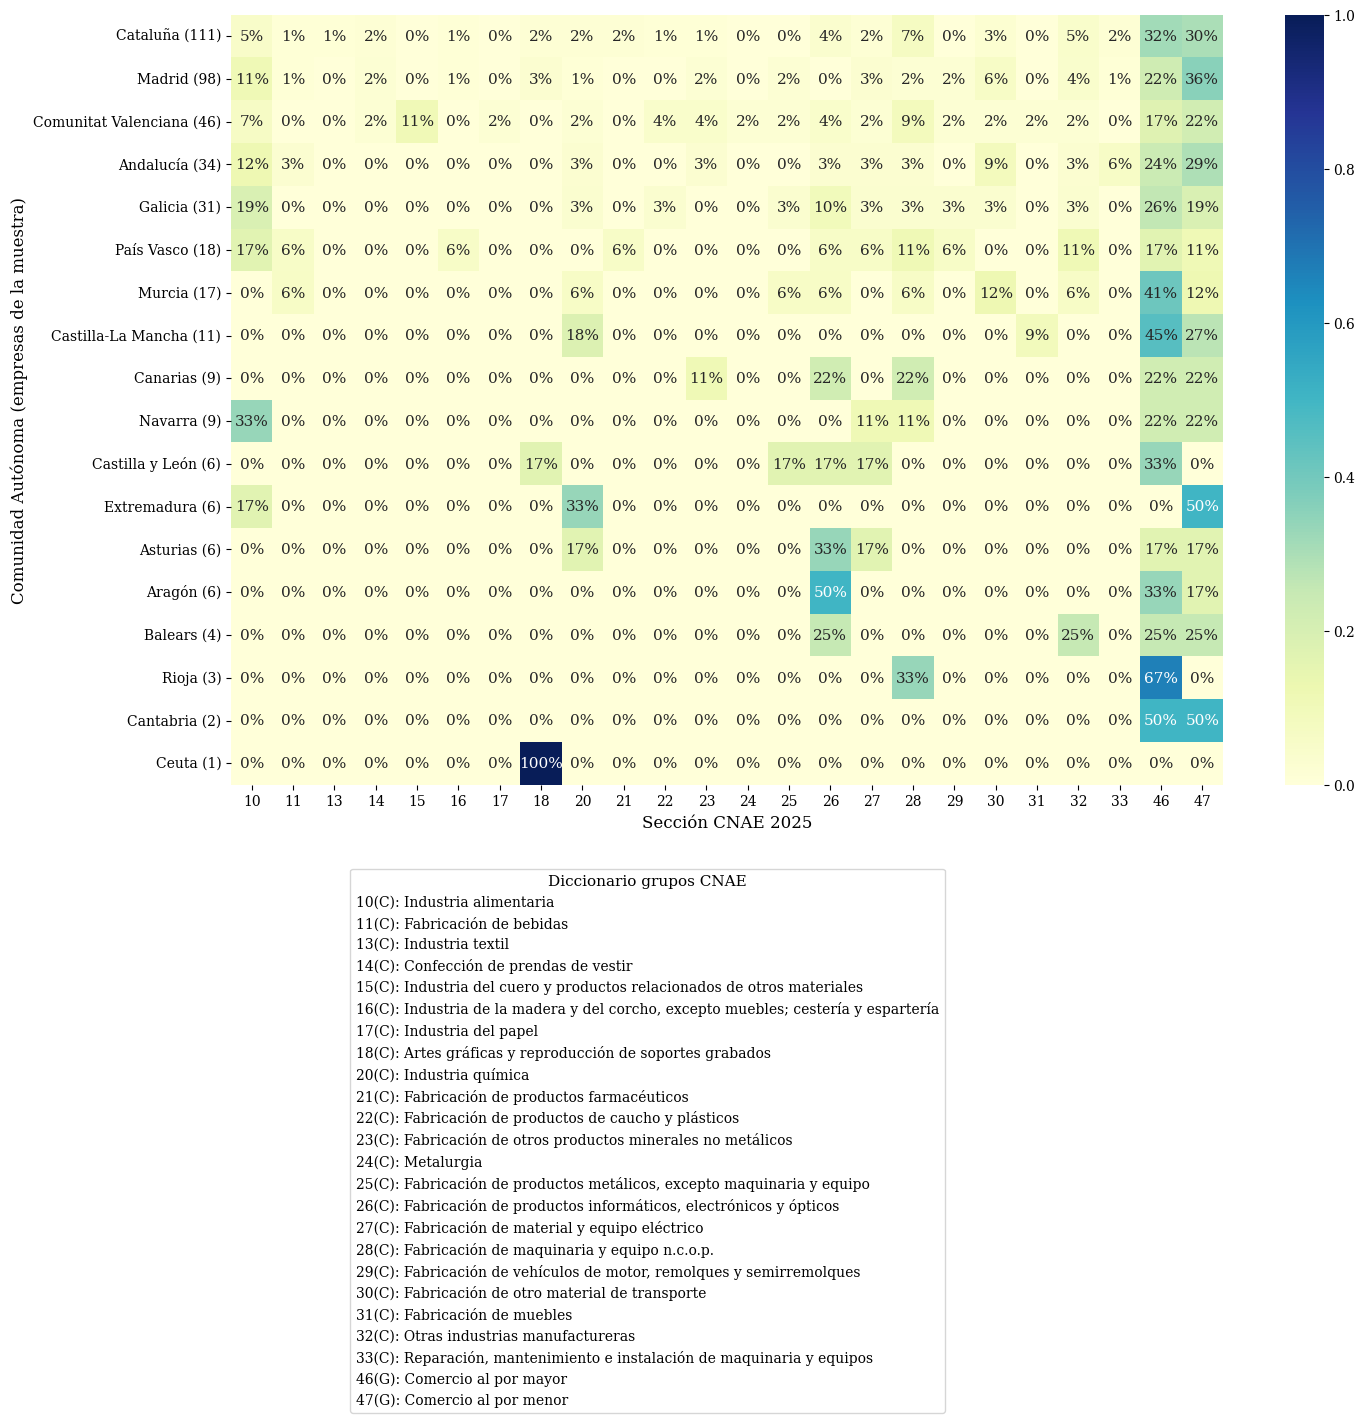

In [23]:
subset_k_n = empresas_df.query("seccion_cnae.isin(['C','G'])").copy()
label_dict = subset_k_n[['grupo_cnae', 'descripcion_grupo_cnae']].drop_duplicates(
).set_index('grupo_cnae')['descripcion_grupo_cnae'].to_dict()
subset_k_n['comunidad_autonoma'] = subset_k_n['comunidad_autonoma'].str.split(
    ',').str[0].str.strip()
orden_volumen = subset_k_n['comunidad_autonoma'].value_counts().index
plt.figure(figsize=(16, 10))
tabla_pct = pd.crosstab(
    subset_k_n['comunidad_autonoma'], subset_k_n['grupo_cnae'], normalize='index')
tabla_pct = tabla_pct.reindex(orden_volumen)
totales_por_ccaa = pd.crosstab(
    subset_k_n['comunidad_autonoma'], subset_k_n['grupo_cnae'], margins=True, margins_name="total")['total'].to_dict()
tabla_pct.index = [
    f"{ccaa} ({totales_por_ccaa[ccaa]})" for ccaa in tabla_pct.index]
ax = sns.heatmap(tabla_pct,
                 annot=True,    # Muestra los números
                 fmt='.0%',     # Formato porcentaje sin decimales (ej. 25%)
                 cmap='YlGnBu')  # Paleta de colores
plt.xlabel("Sección CNAE 2025")
plt.ylabel("Comunidad Autónoma (empresas de la muestra)")

#plt.title("Distribución Porcentual de la actividad de las empresas emergentes según CCAA")

visible_ticks = [t.get_text() for t in ax.get_xticklabels()]

# Create handles ONLY for the keys found on the axis
cnae_2025_df = pd.read_csv(
    "../data/silver/cnae_2025.csv", sep=";", dtype=str)
grupo_seccion_dict = cnae_2025_df.set_index('grupo')['seccion'].to_dict()
legend_handles = []
for key in visible_ticks:
    if key in label_dict:
        # Create the text-only entry
        label_text = f"{key}({grupo_seccion_dict.get(key, 'N/A')}): {label_dict[key]}"
        handle = mpatches.Patch(color='none', label=label_text)
        legend_handles.append(handle)

plt.legend(
    handles=legend_handles,
    bbox_to_anchor=(0.42, -0.1),   # Move legend outside to the right
    loc='upper center',          # Anchor point
    title="Diccionario grupos CNAE",       # Title for the legend
    handlelength=0,
    handletextpad=0,
    frameon=True                # Add a box around the legend
)
#plt.savefig("../docs/manuscrito/recursos/figuras/matriz-actividad-ccaa-c-g.pdf",
#            format='pdf',
#            bbox_inches='tight',
#            pad_inches=0.05)
plt.show()

# Actividad por provincias

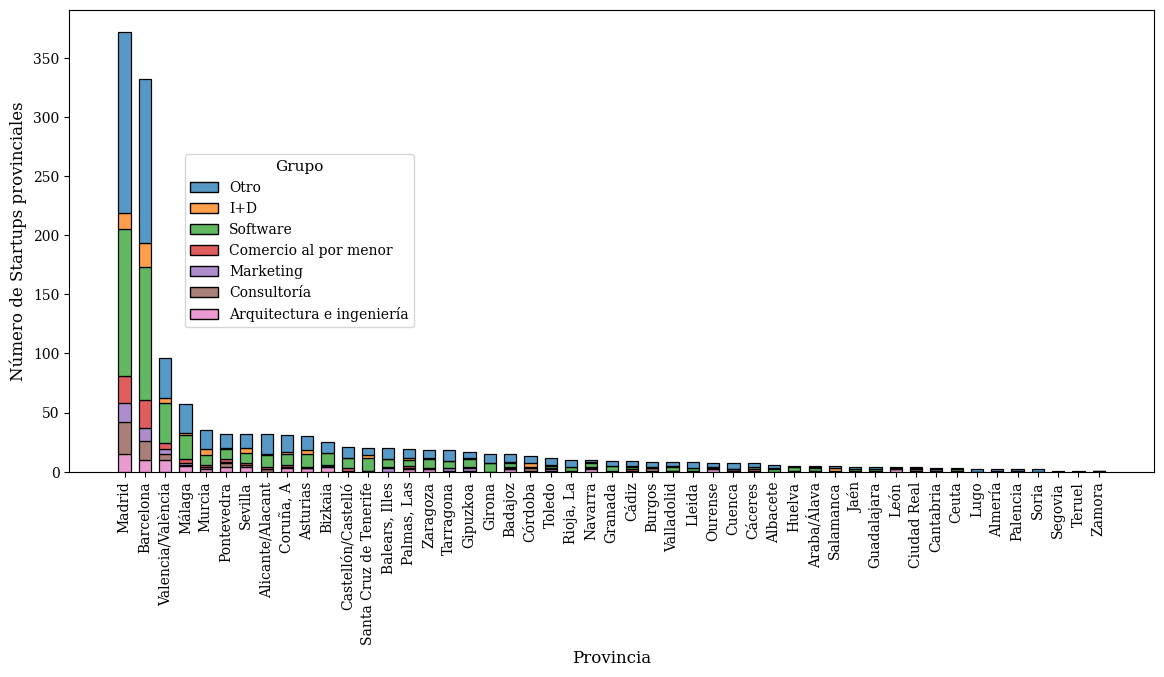

In [33]:
plt.figure(figsize=(14, 6))
anno = 2021
annos = [2021, 2022, 2023, 2024]

subset = empresas_df.query("anno_constitucion == @annos").copy()
dict_grupo = {'62': 'Software', '72': 'I+D', '71': 'Arquitectura e ingeniería', '73': 'Marketing', '70': 'Consultoría', '47': 'Comercio al por menor'}
subset["Grupo"] = subset['grupo_cnae'].apply(lambda x: "Otro" if x not in ['72', '62', '70', '71', '73', '47']  else dict_grupo.get(x, "Otro"))
subset['categoria_ubicacion'] = pd.Categorical(
    subset['provincia'], categories=subset['provincia'].value_counts().index.tolist(), ordered=True)

ax = sns.histplot(data=subset, x='categoria_ubicacion',
                  hue='Grupo', multiple="stack", shrink=0.6, palette='tab10')

plt.ylabel('Número de Startups provinciales')
plt.xlabel('Provincia')
plt.xticks(rotation=90)
sns.move_legend(ax, "center left", bbox_to_anchor=(0.1, 0.5))
#plt.savefig("../docs/manuscrito/recursos/figuras/distribucion-startups-provincia-grupo.pdf",
#            format='pdf',
#            bbox_inches='tight',
#            pad_inches=0.05)
plt.show()

# Correlación poblacional

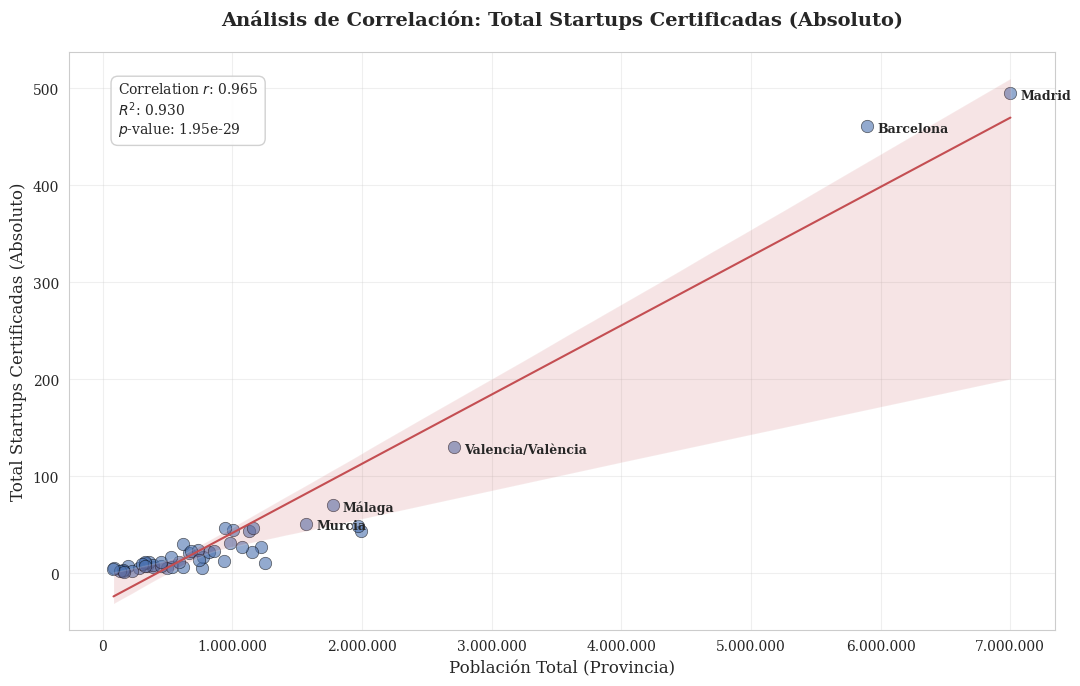

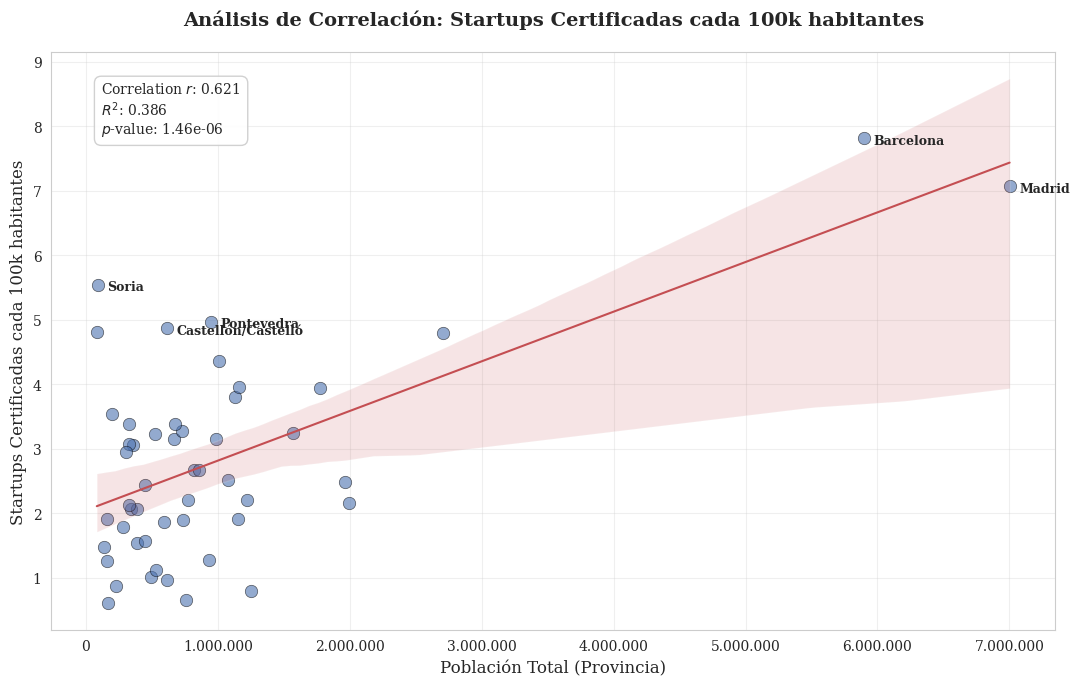

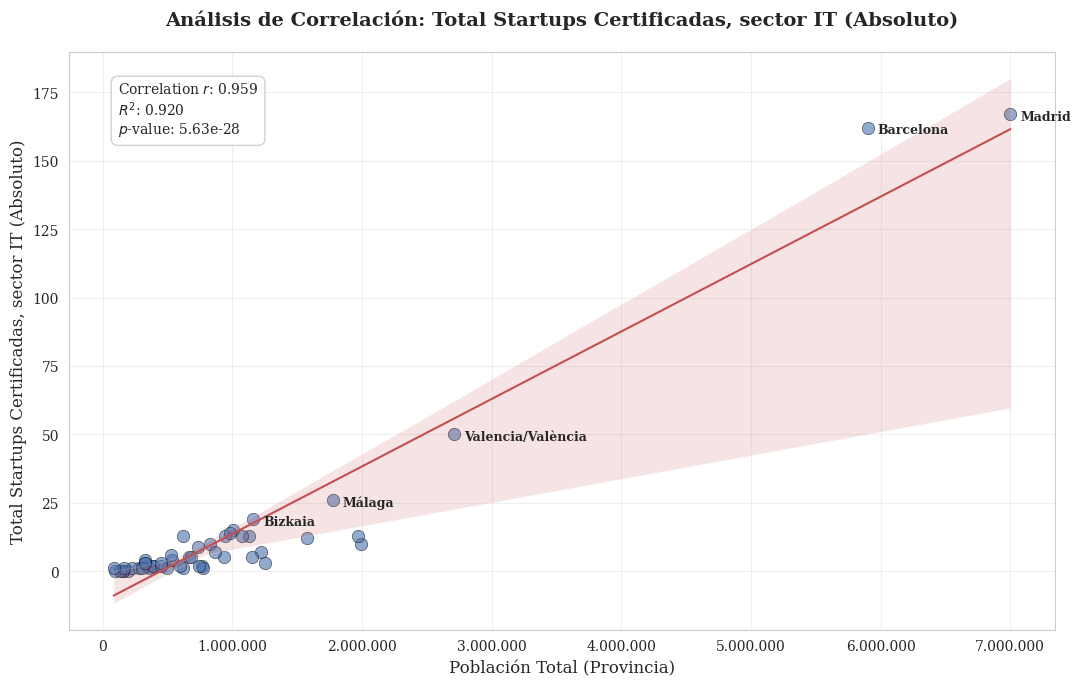

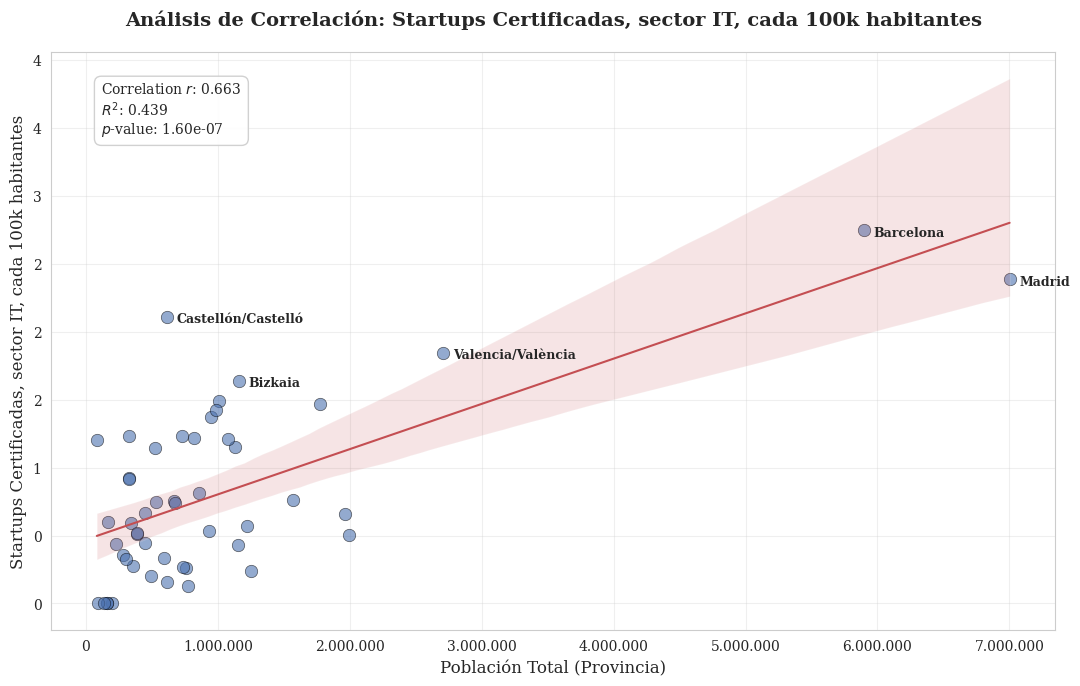

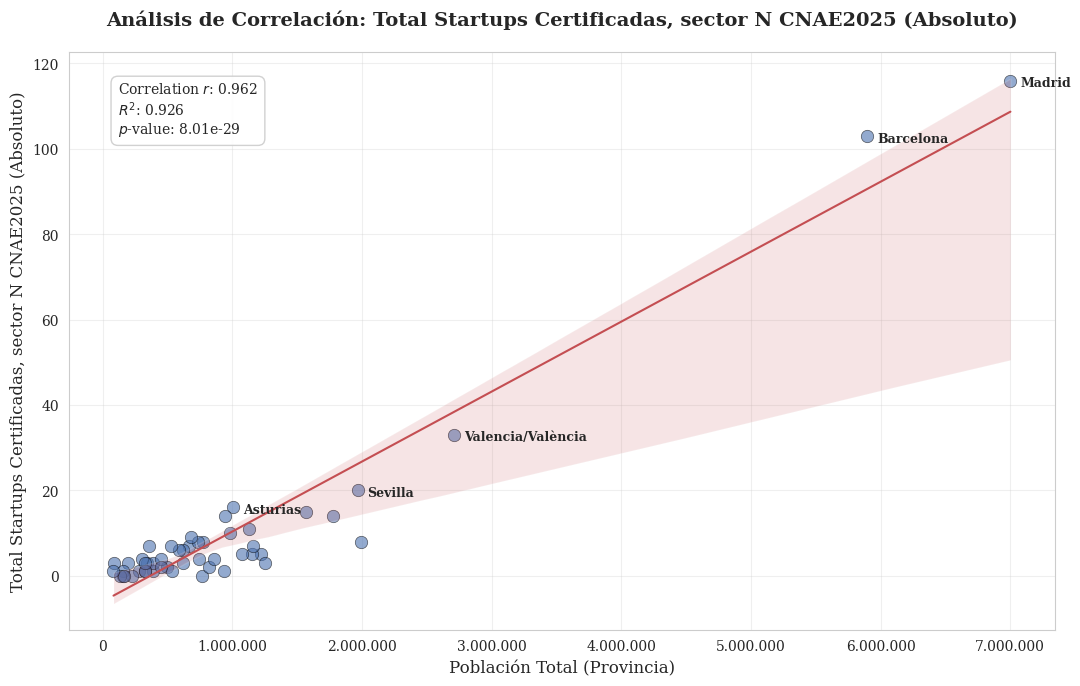

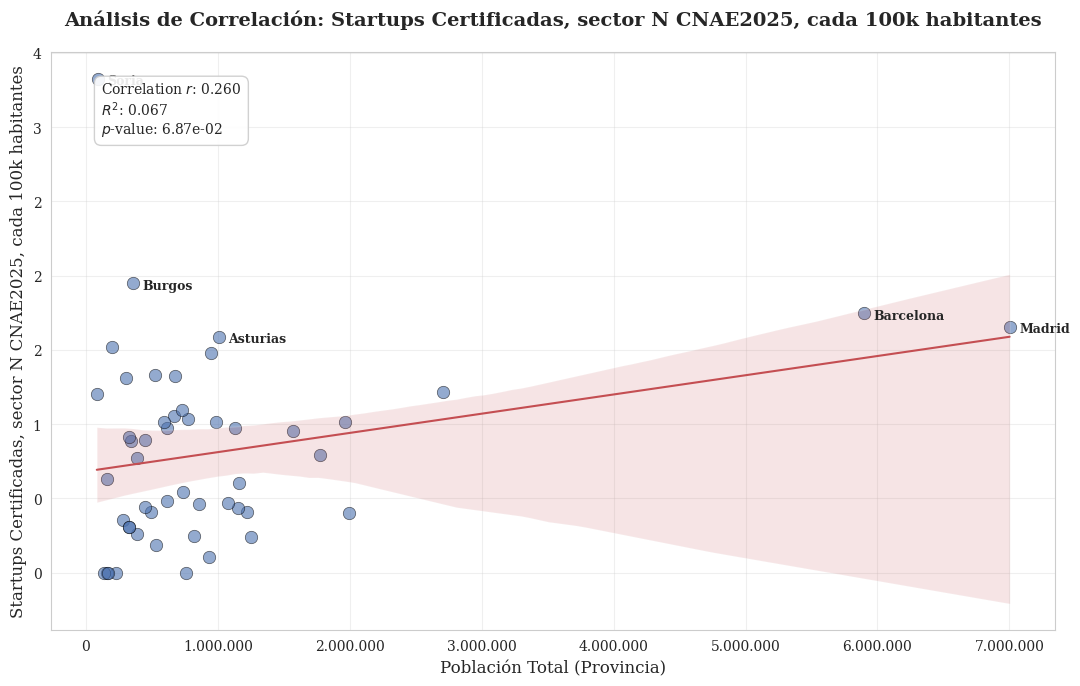

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({
    "font.family": "serif",   # Fuente con serifa para coherencia con el texto
    "font.size": 11,          # Tamaño base
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "grid.alpha": 0.3         # Rejilla más sutil
})

# 1. PROCESAMIENTO DE DATOS
# Cargar población (una sola vez)
poblacion_df = pd.read_parquet("../data/silver/poblacion_2024.parquet")
poblacion_df = poblacion_df.groupby('cpro').agg({
    'poblacion': 'sum',
    'hombres': 'sum',
    'mujeres': 'sum'
}).reset_index()

# Procesar empresas
# Aseguramos que cpro sea string para evitar problemas con ceros a la izquierda (ej. 08 Barcelona)
empresas_df['cpro'] = empresas_df['codigo_postal'].astype(str).str.zfill(5).str[:2]

# Agrupación por provincia y sección
empresa_provincial_df = (
    empresas_df.query('anno_constitucion <= 2024')
    .groupby(['cpro', 'seccion_cnae'])
    .size()
    .reset_index(name='num_empresas')
)

# Pivoteo eficiente: Convertimos las secciones en columnas
provincial_df = empresa_provincial_df.pivot(index='cpro', columns='seccion_cnae', values='num_empresas').fillna(0)
secciones = provincial_df.columns.tolist()

# Añadimos el total de empresas (num_empresas) antes del pivoteo o sumando las filas
provincial_df['total_absoluto'] = provincial_df.sum(axis=1)
provincial_df = provincial_df.reset_index()

# Merge con población
provincial_df = provincial_df.merge(poblacion_df, on='cpro', how='left')

# Cálculos de densidad (por 100k hab)
provincial_df['total_100k_hab'] = (provincial_df['total_absoluto'] / provincial_df['poblacion']) * 100000

cols_densidad = []
for seccion in secciones:
    col_name = f'{seccion.lower()}_100k_hab'
    cols_densidad.append(col_name)
    provincial_df[col_name] = (provincial_df[seccion] / provincial_df['poblacion']) * 100000

# Mapeo de nombres de provincias
provincias_ine = pd.read_csv("../data/silver/ine_ccaa_y_provincias.csv", sep=";", dtype={'cpro': str})
cpro_dict = provincias_ine.set_index('cpro')['provincia'].to_dict()
provincial_df['provincia'] = provincial_df['cpro'].map(cpro_dict)

# Guardar resultado limpio
provincial_df.to_csv('densidad_empresas.csv', index=False, sep=";")

# 2. FUNCIÓN DE VISUALIZACIÓN MEJORADA

def plot_scatter_empresas(df_plot, x_col, y_col, titulo_y, top_n=5):
    """
    Genera un scatterplot adaptado al estilo visual de la memoria de tesis.
    """
    # Aplicamos el estilo de rejilla de seaborn pero sin resetear las fuentes
    sns.set_style("whitegrid", {"font.family": "serif"})
    
    plt.figure(figsize=(11, 7)) # Tamaño ajustado para encajar bien en un A4
    
    # Limpieza de datos
    temp_df = df_plot[[x_col, y_col, 'provincia']].dropna()
    
    # Estadísticos
    r, p_val = stats.pearsonr(temp_df[x_col], temp_df[y_col])
    r2 = r**2

    # Gráfico y Regresión
    # Usamos colores más "sobrios" para el entorno académico
    sns.regplot(
        data=temp_df, x=x_col, y=y_col,
        # Cambiamos 'linewidth' por 'linewidths' (con 's' al final)
        scatter_kws={'s':80, 'color':'#4C72B0', 'alpha':0.6, 'edgecolor':'black', 'linewidths':0.5},
        line_kws={'color':'#C44E52', 'lw':1.5}
    )

    # Etiquetas Top N (con fuente serif)
    top_provincias = temp_df.nlargest(top_n, y_col)
    for _, row in top_provincias.iterrows():
        plt.annotate(
            row['provincia'], 
            (row[x_col], row[y_col]),
            xytext=(7, -4), 
            textcoords='offset points',
            fontsize=9, 
            fontfamily='serif',
            fontweight='bold'
        )

    # Cuadro de métricas (Elegante y minimalista)
    stats_text = (r'Correlation $r$: ' + f'{r:.3f}\n' +
                  r'$R^2$: ' + f'{r2:.3f}\n' +
                  r'$p$-value: ' + f'{p_val:.2e}')
    
    plt.gca().text(
        0.05, 0.95, stats_text, 
        transform=plt.gca().transAxes,
        fontsize=10, 
        verticalalignment='top', 
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='0.8')
    )

    # Formateo de títulos y ejes
    plt.title(f'Análisis de Correlación: {titulo_y}', pad=20)
    plt.xlabel('Población Total (Provincia)')
    plt.ylabel(titulo_y)
    
    # Formateo de miles con punto (Estilo español)
    fmt = FuncFormatter(lambda x, _: '{:,.0f}'.format(x).replace(',', '.'))
    plt.gca().xaxis.set_major_formatter(fmt)
    plt.gca().yaxis.set_major_formatter(fmt)

    plt.tight_layout()
    
    # Opcional: Guardar automáticamente para la memoria
    # plt.savefig(f"grafico_{y_col}.pdf", bbox_inches='tight') 
    plt.show()

# 3. EJECUCIÓN DE GRÁFICOS

plot_scatter_empresas(provincial_df, 'poblacion', 'total_absoluto', 'Total Startups Certificadas (Absoluto)', top_n=5)
plot_scatter_empresas(provincial_df, 'poblacion', 'total_100k_hab', 'Startups Certificadas cada 100k habitantes', top_n=5)

plot_scatter_empresas(provincial_df, 'poblacion', 'K', 'Total Startups Certificadas, sector IT (Absoluto)', top_n=5)
plot_scatter_empresas(provincial_df, 'poblacion', 'k_100k_hab', 'Startups Certificadas, sector IT, cada 100k habitantes', top_n=5)

plot_scatter_empresas(provincial_df, 'poblacion', 'N', 'Total Startups Certificadas, sector N CNAE2025 (Absoluto)', top_n=5)
plot_scatter_empresas(provincial_df, 'poblacion', 'n_100k_hab', 'Startups Certificadas, sector N CNAE2025, cada 100k habitantes', top_n=5)


Aparentemente la población provincial explicaría casi a la perfección la aparición de las startups, pero no es así. el análisis en función de la densidad de startups por cada 100.000 habitantes revela que no lo explica a la perfección a nivel generanl ni en función del sector o sección CNAE.